In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("/Users/user/Desktop/NYU/Data-Science-Bootcamp/project/data.csv", low_memory=False, encoding="ISO-8859-1")

In [4]:
data.shape

(435742, 13)

In [5]:
data.head(10)

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01
5,152,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.4,25.7,NaN,NaN,NaN,NaN,1990-03-01
6,150,April - M041990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",5.4,17.1,NaN,NaN,NaN,NaN,1990-04-01
7,151,April - M041990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,8.7,NaN,NaN,NaN,NaN,1990-04-01
8,152,April - M041990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.2,23.0,NaN,NaN,NaN,NaN,1990-04-01
9,151,May - M051990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.0,8.9,NaN,NaN,NaN,NaN,1990-05-01


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  object 
dtyp

In [7]:
data.describe()

,so2,no2,rspm,spm,pm2_5
count,401096.000000,419509.000000,395520.000000,198355.000000,9314.000000
mean,10.829414,25.809623,108.832784,220.783480,40.791467
std,11.177187,18.503086,74.872430,151.395457,30.832525
min,0.000000,0.000000,0.000000,0.000000,3.000000
25%,5.000000,14.000000,56.000000,111.000000,24.000000
50%,8.000000,22.000000,90.000000,187.000000,32.000000
75%,13.700000,32.200000,142.000000,296.000000,46.000000
max,909.000000,876.000000,6307.033333,3380.000000,504.000000


In [24]:
data['state'].unique()

array(['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadra & Nagar Haveli',
       'Daman & Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana',
       'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka',
       'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya',
       'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh',
       'Uttarakhand', 'Uttaranchal', 'West Bengal',
       'andaman-and-nicobar-islands', 'Lakshadweep', 'Tripura'],
      dtype=object)

In [8]:
state_counts = data['state'].value_counts()
print(state_counts)

state
Maharashtra                    60384
Uttar Pradesh                  42816
Andhra Pradesh                 26368
Punjab                         25634
Rajasthan                      25589
Kerala                         24728
Himachal Pradesh               22896
West Bengal                    22463
Gujarat                        21279
Tamil Nadu                     20597
Madhya Pradesh                 19920
Assam                          19361
Odisha                         19279
Karnataka                      17119
Delhi                           8551
Chandigarh                      8520
Chhattisgarh                    7831
Goa                             6206
Jharkhand                       5968
Mizoram                         5338
Telangana                       3978
Meghalaya                       3853
Puducherry                      3785
Haryana                         3420
Nagaland                        2463
Bihar                           2275
Uttarakhand                     

In [9]:
data['date'] = pd.to_datetime(data['date'])

In [10]:
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month

In [11]:
# Winter: December, January, February (12, 1, 2)
# Spring: March, April, May (3, 4, 5)
# Summer: June, July, August (6, 7, 8)
# Autumn: September, October, November (9, 10, 11)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else: # 9 10 11
        return 'Autumn'

In [12]:
#Giving each data point a season :)
data['season'] = data['month'].apply(get_season)

season_counts = data['season'].value_counts()
print(season_counts)

season
Spring    111946
Autumn    108814
Summer    108398
Winter    106584
Name: count, dtype: int64


In [30]:
# Compinting hte seasonaal data average for each season
seasonal_data = data.groupby(['state', 'season']).agg({
    'so2': 'mean',
    'no2': 'mean',
    'rspm': 'mean',
    'spm': 'mean',
    'pm2_5': 'mean'
}).reset_index()

# Display the result
print("Average air quality parameters by state and season:")
# seasonal_data.head() some reason head is not printing
print(seasonal_data.head())

# Calculate overall seasonal averages across all states
overall_seasonal_avg = data.groupby('season').agg({
    'so2': 'mean',
    'no2': 'mean',
    'rspm': 'mean',
    'spm': 'mean',
    'pm2_5': 'mean'
}).reset_index()

print("\nOverall seasonal averages across all states:")
overall_seasonal_avg

Average air quality parameters by state and season:
               state  season       so2        no2       rspm         spm  \
0     Andhra Pradesh  Autumn  7.345714  22.070163  76.833160  197.477176   
1     Andhra Pradesh  Spring  7.255656  21.721324  80.980291  204.869008   
2     Andhra Pradesh  Summer  6.943148  20.524696  71.901160  186.047666   
3     Andhra Pradesh  Winter  7.623115  22.564256  83.436605  213.410568   
4  Arunachal Pradesh  Autumn  3.960000   5.250000  64.558824         NaN   

   pm2_5  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  

Overall seasonal averages across all states:


,season,so2,no2,rspm,spm,pm2_5
0,Autumn,10.725421,25.925381,107.230656,212.963382,42.398380
1,Spring,11.014428,25.839858,113.024470,235.486063,41.355300
2,Summer,10.103607,23.740510,93.359950,190.025437,33.215673
3,Winter,11.471015,27.749947,121.888200,244.950863,45.992236


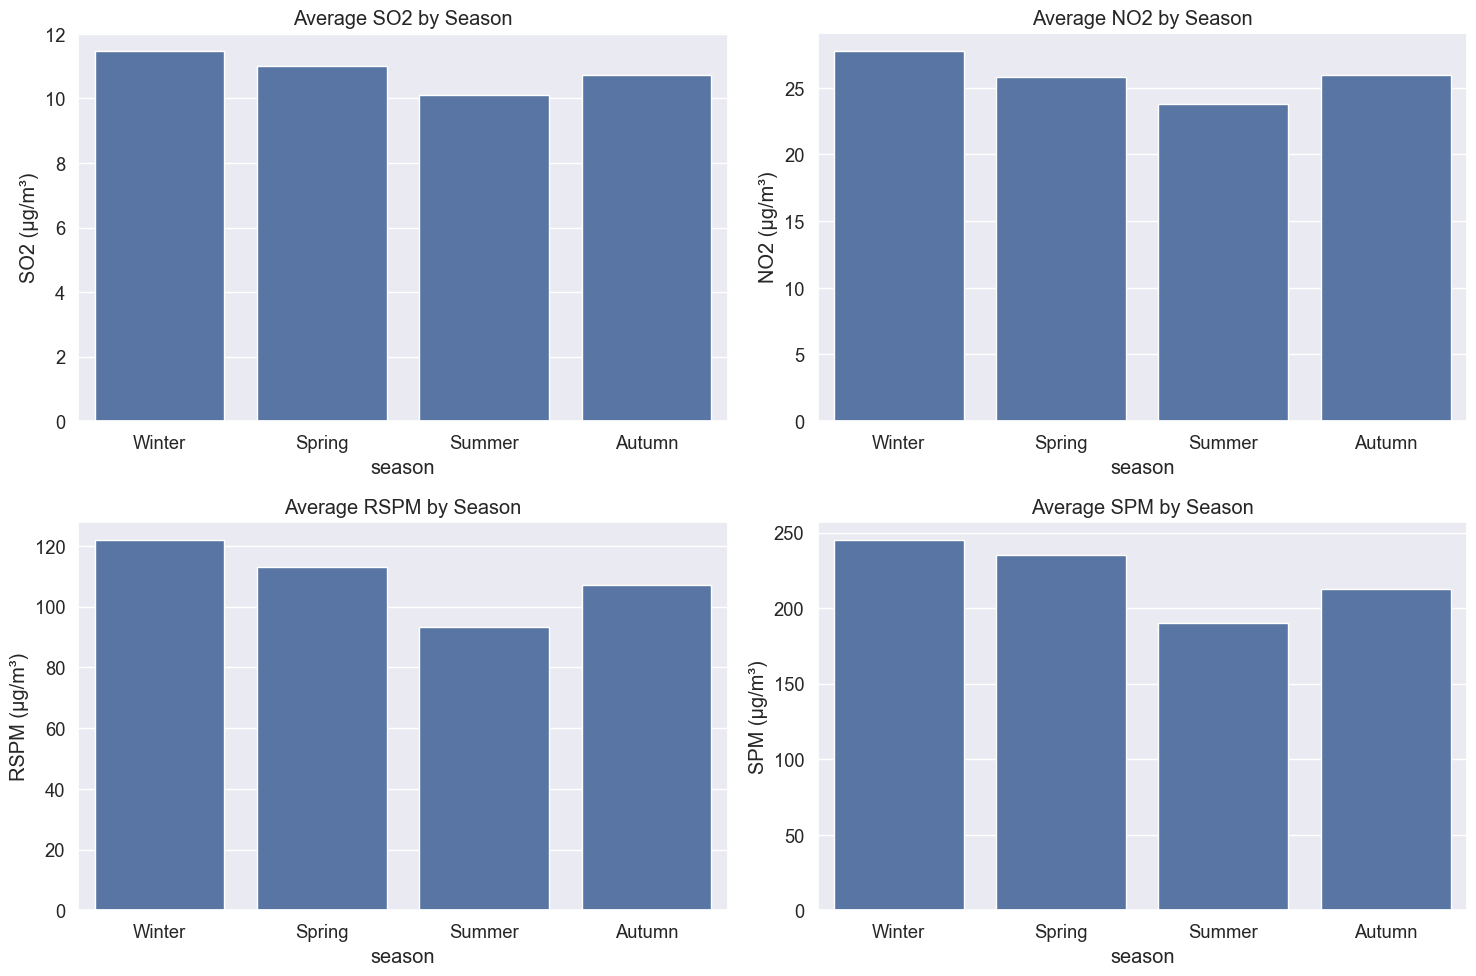

In [16]:
# Now we are doing some plotting :)
# Set plotting style
plt.style.use('ggplot')
sns.set(font_scale=1.2)

# Create a figure for visualizing overall seasonal trends
plt.figure(figsize=(15, 10))

# Plot SO2 by season
plt.subplot(2, 2, 1)
sns.barplot(x='season', y='so2', data=overall_seasonal_avg, order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title('Average SO2 by Season')
plt.ylabel('SO2 (μg/m³)')

# Plot NO2 by season
plt.subplot(2, 2, 2)
sns.barplot(x='season', y='no2', data=overall_seasonal_avg, order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title('Average NO2 by Season')
plt.ylabel('NO2 (μg/m³)')

# Plot RSPM by season
plt.subplot(2, 2, 3)
sns.barplot(x='season', y='rspm', data=overall_seasonal_avg, order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title('Average RSPM by Season')
plt.ylabel('RSPM (μg/m³)')

# Plot SPM by season
plt.subplot(2, 2, 4)
sns.barplot(x='season', y='spm', data=overall_seasonal_avg, order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title('Average SPM by Season')
plt.ylabel('SPM (μg/m³)')

plt.tight_layout()
plt.savefig('seasonal_air_quality_overall.png')
plt.show()

# all this stuff extra 

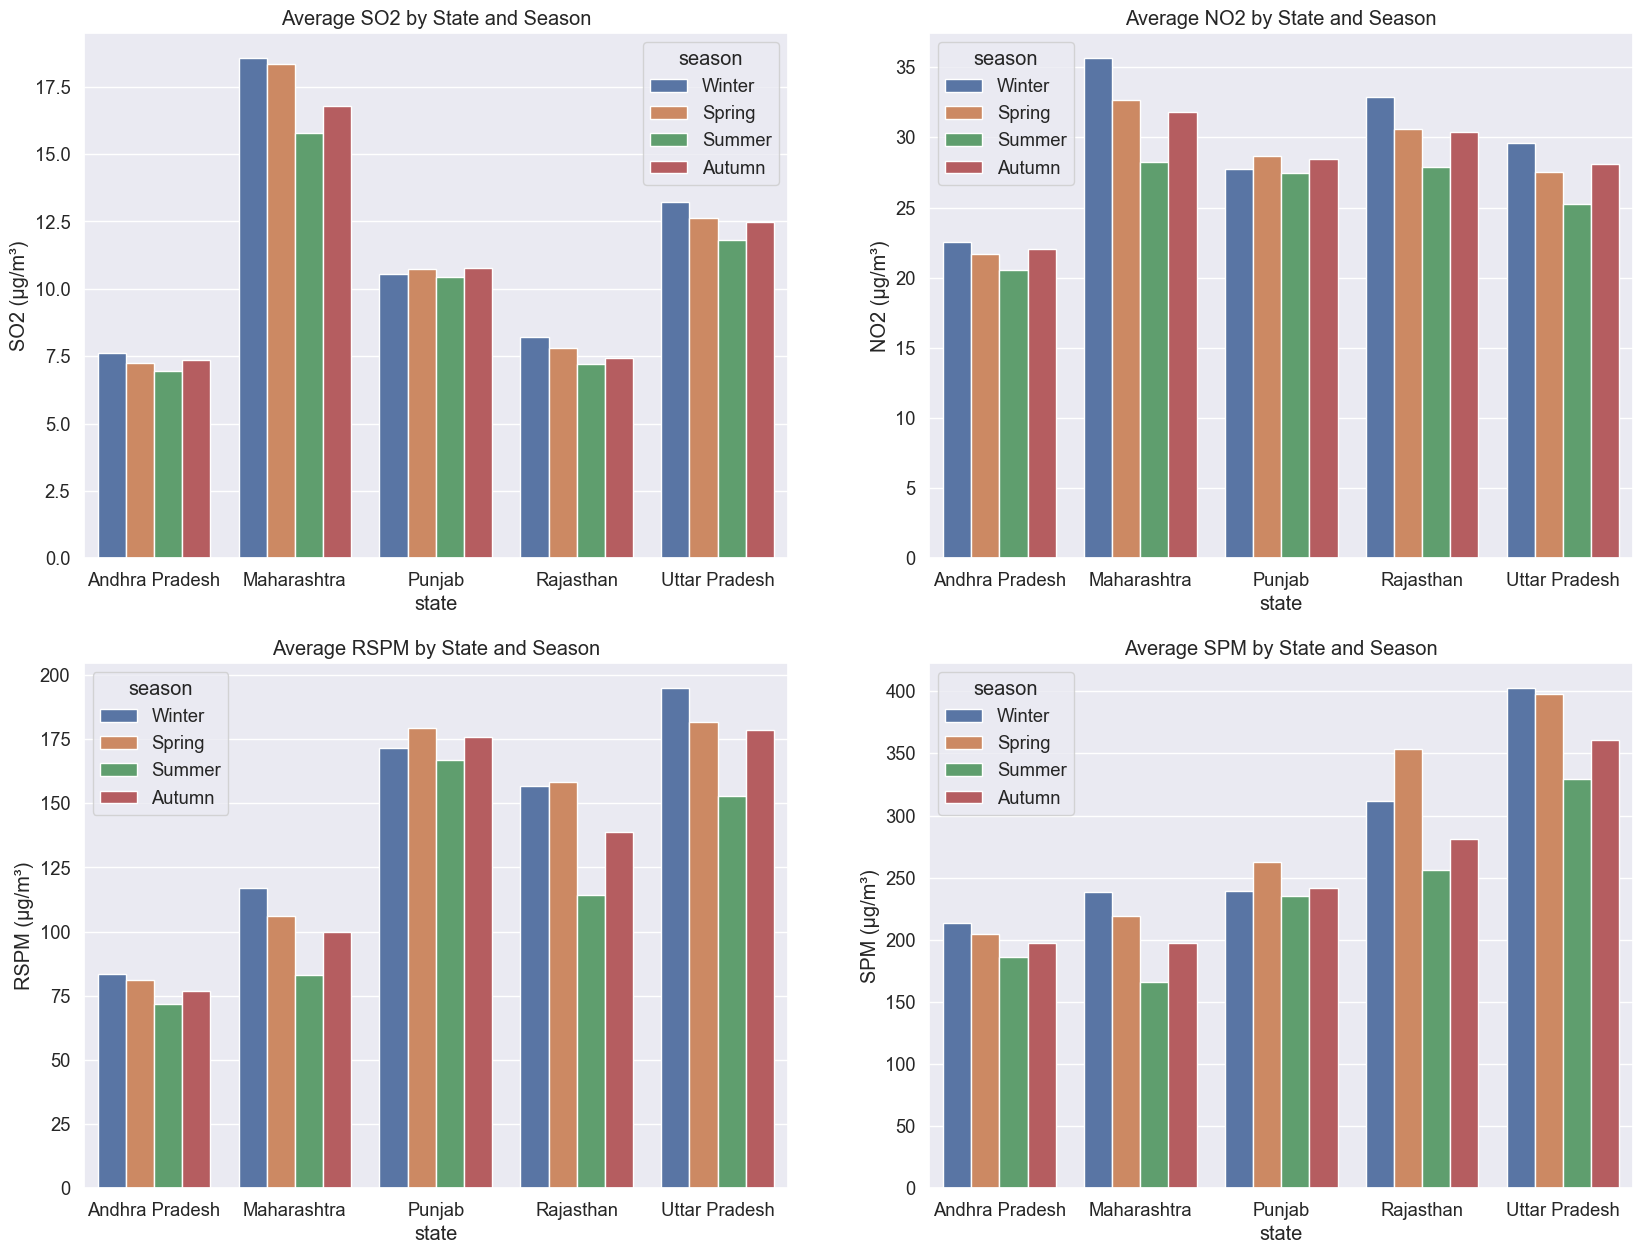

In [36]:
# Select top 5 states by data availability
top_states = state_counts.head(5).index.tolist()

# Filter data for top states
top_states_data = seasonal_data[seasonal_data['state'].isin(top_states)]

# Create plots for each air quality parameter across top states by season
plt.figure(figsize=(20, 15))

# Plot SO2 by state and season
plt.subplot(2, 2, 1)
sns.barplot(x='state', y='so2', hue='season', data=top_states_data, 
           hue_order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title('Average SO2 by State and Season')
plt.ylabel('SO2 (μg/m³)')
# plt.xticks(rotation=45)

# Plot NO2 by state and season
plt.subplot(2, 2, 2)
sns.barplot(x='state', y='no2', hue='season', data=top_states_data,
           hue_order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title('Average NO2 by State and Season')
plt.ylabel('NO2 (μg/m³)')

# Plot RSPM by state and season
plt.subplot(2, 2, 3)
sns.barplot(x='state', y='rspm', hue='season', data=top_states_data,
           hue_order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title('Average RSPM by State and Season')
plt.ylabel('RSPM (μg/m³)')

# Plot SPM by state and season
plt.subplot(2, 2, 4)
sns.barplot(x='state', y='spm', hue='season', data=top_states_data,
           hue_order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title('Average SPM by State and Season')
plt.ylabel('SPM (μg/m³)')

plt.show()

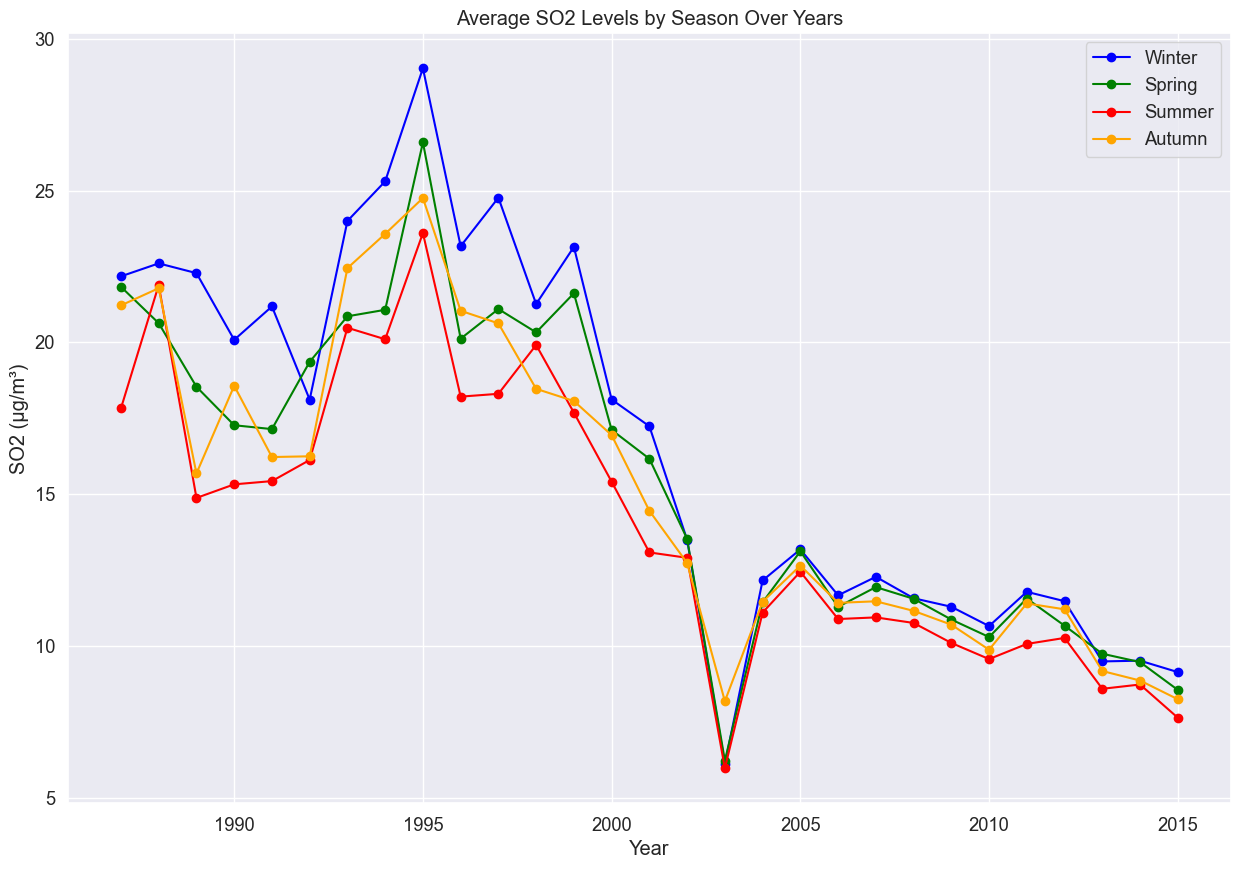

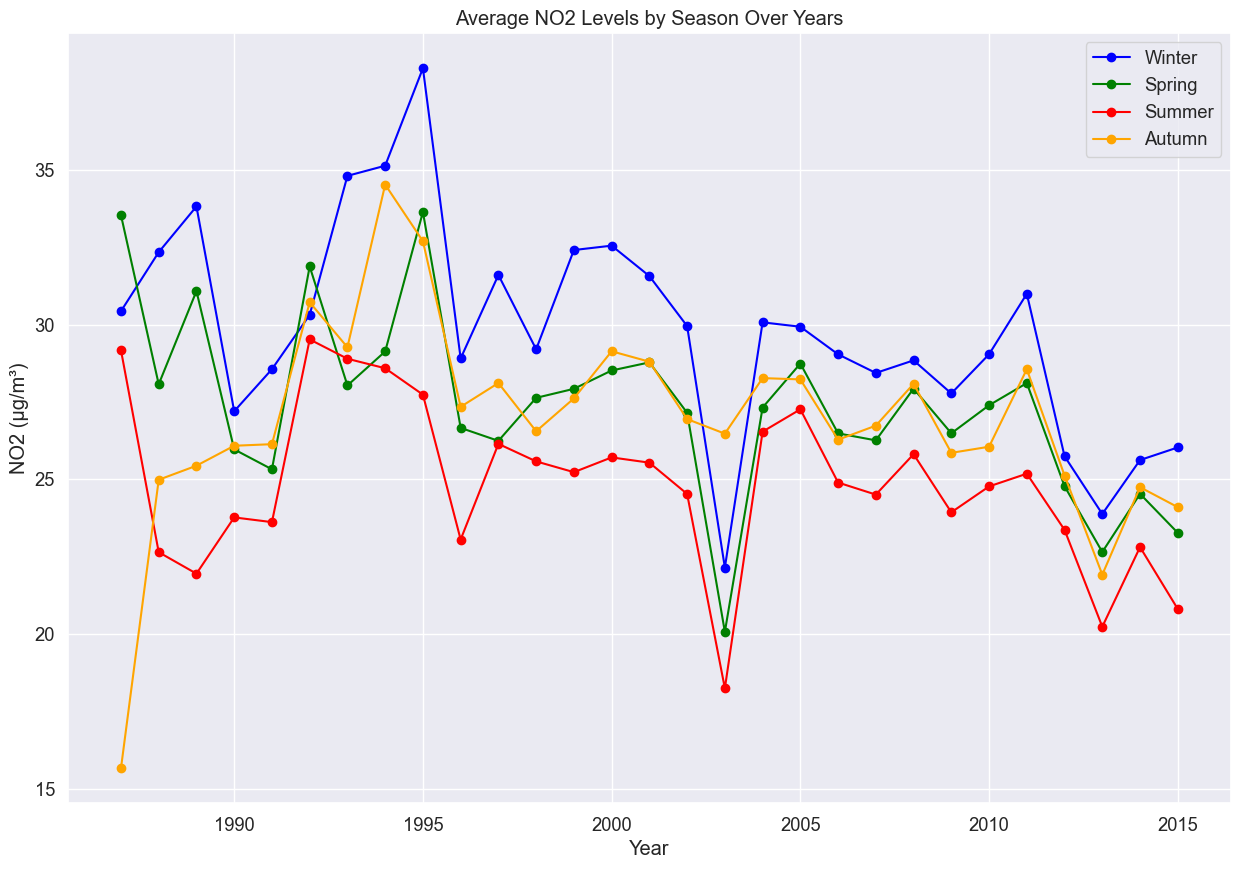

In [34]:
# Create a time series of yearly averages by season
yearly_seasonal_data = data.groupby(['year', 'season']).agg({
    'so2': 'mean',
    'no2': 'mean',
    'rspm': 'mean',
    'spm': 'mean'
}).reset_index()

# Plot time series for SO2 by season
plt.figure(figsize=(15, 10))

seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
colors = ['blue', 'green', 'red', 'orange']

for i, season in enumerate(seasons):
    season_data = yearly_seasonal_data[yearly_seasonal_data['season'] == season]
    plt.plot(season_data['year'], season_data['so2'], marker='o', label=season, color=colors[i])

plt.title('Average SO2 Levels by Season Over Years')
plt.xlabel('Year')
plt.ylabel('SO2 (μg/m³)')
plt.legend()
plt.grid(True)
plt.show()

# Plot time series for NO2 by season
plt.figure(figsize=(15, 10))

for i, season in enumerate(seasons):
    season_data = yearly_seasonal_data[yearly_seasonal_data['season'] == season]
    plt.plot(season_data['year'], season_data['no2'], marker='o', label=season, color=colors[i])

plt.title('Average NO2 Levels by Season Over Years')
plt.xlabel('Year')
plt.ylabel('NO2 (μg/m³)')
plt.legend()
plt.grid(True)
plt.show()

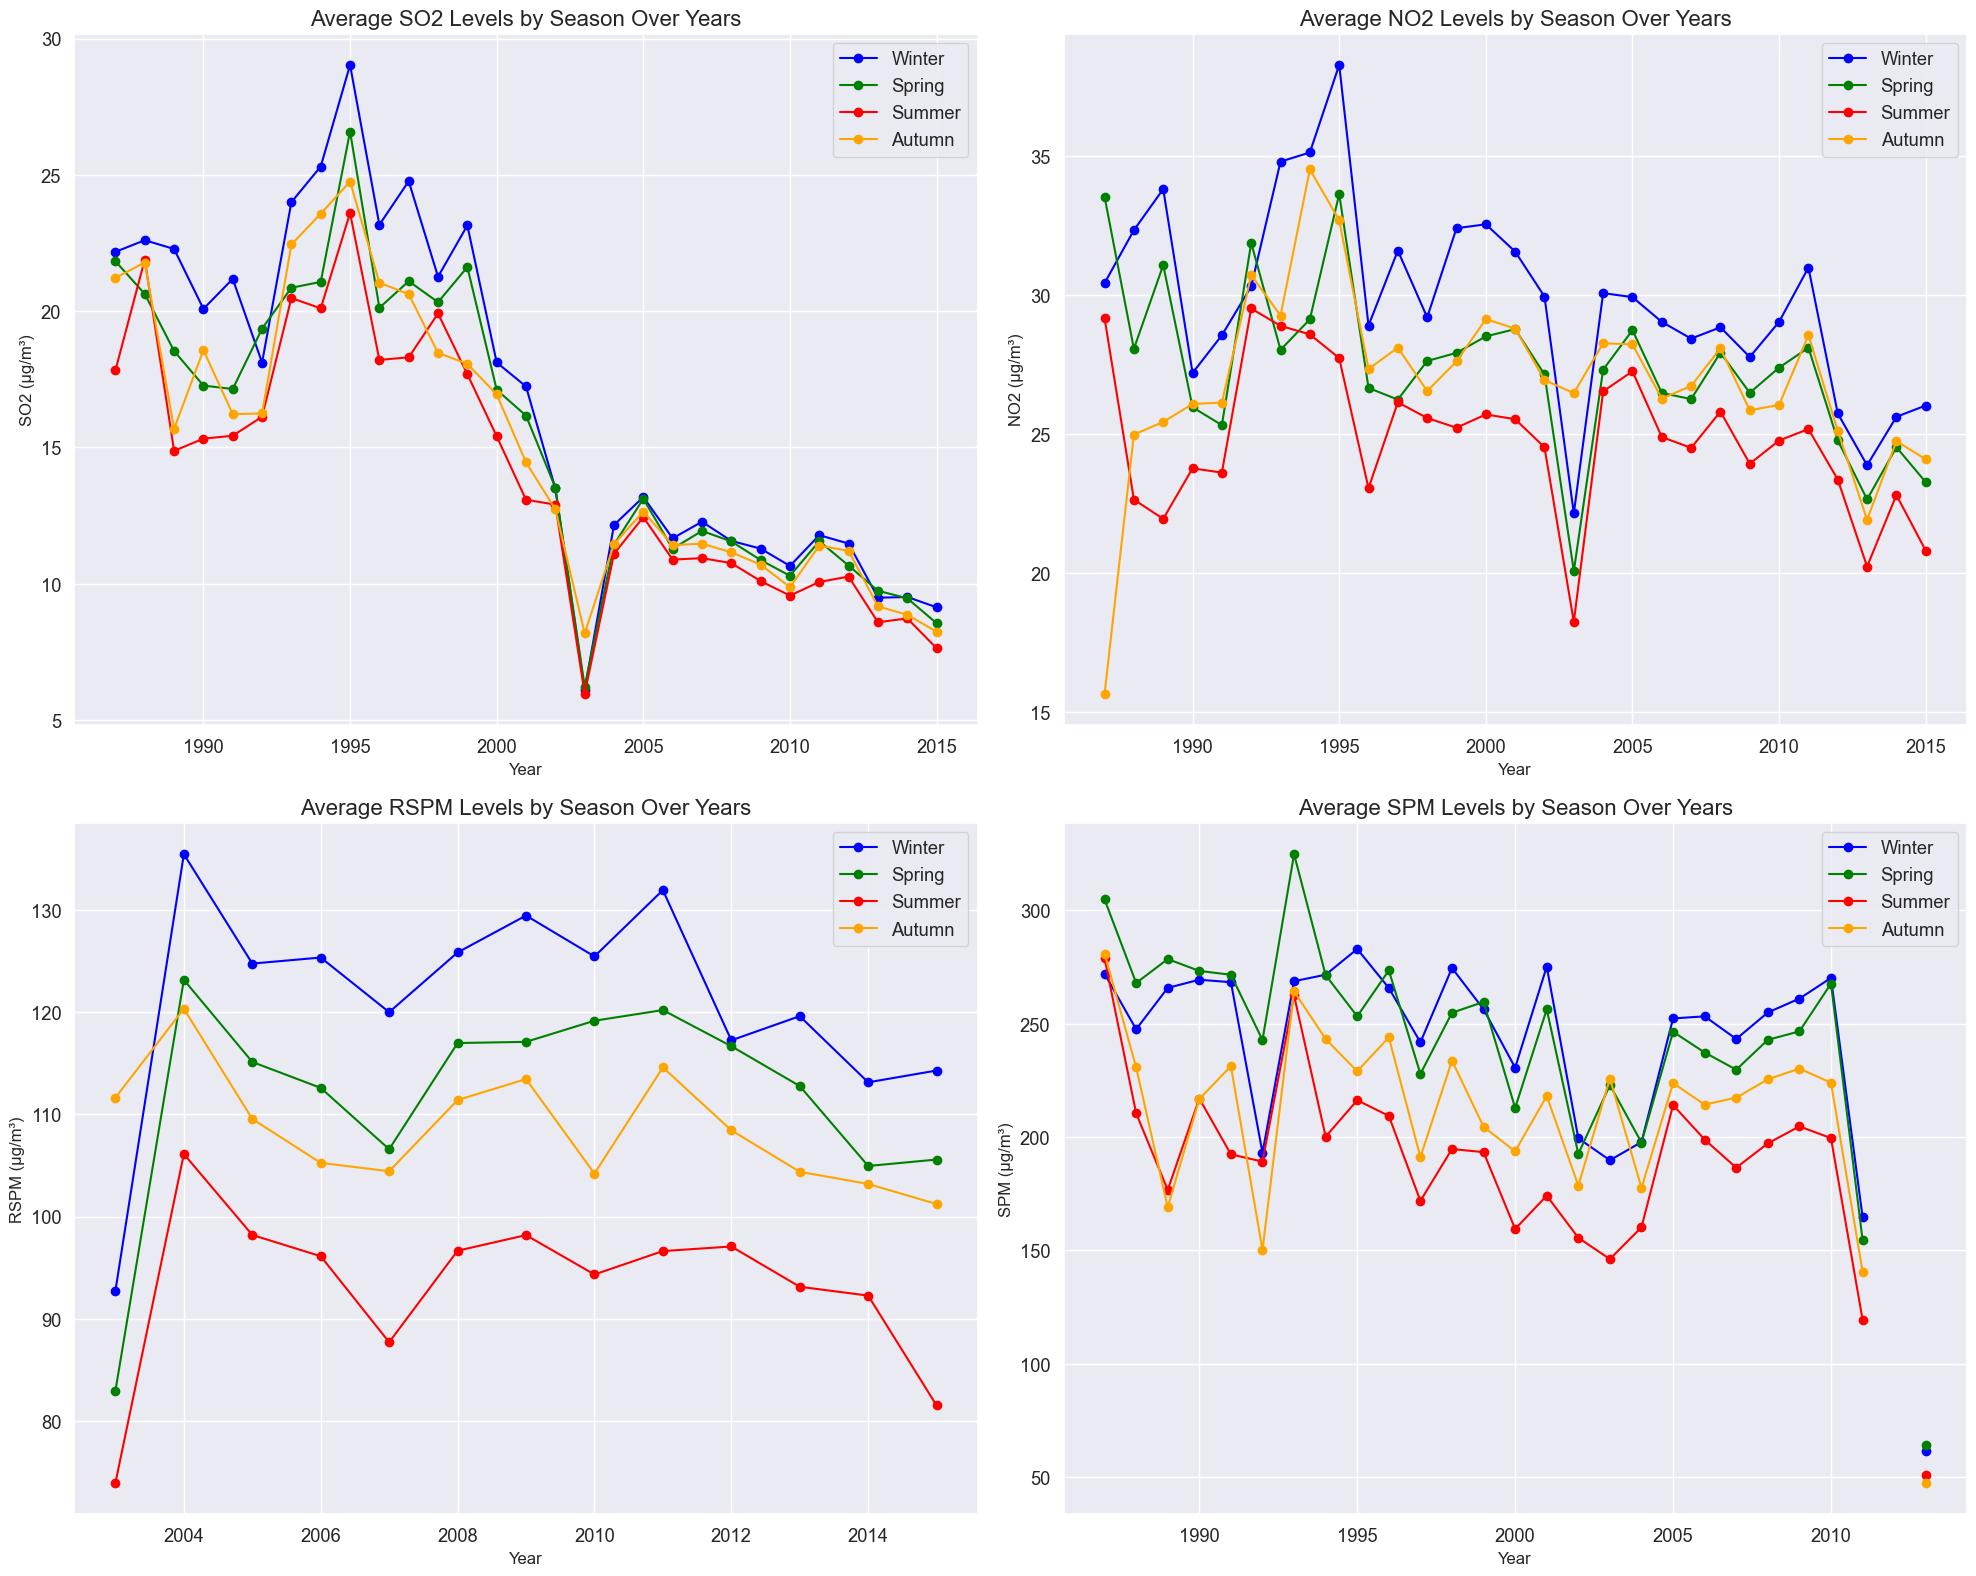

In [37]:
# Create a time series of yearly averages by season
yearly_seasonal_data = data.groupby(['year', 'season']).agg({
    'so2': 'mean',
    'no2': 'mean',
    'rspm': 'mean',
    'spm': 'mean'
}).reset_index()

# Create a figure with 4 subplots (2x2 grid) for the four metrics
plt.figure(figsize=(20, 16))
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
colors = ['blue', 'green', 'red', 'orange']

# Plot time series for SO2 by season
plt.subplot(2, 2, 1)
for i, season in enumerate(seasons):
    season_data = yearly_seasonal_data[yearly_seasonal_data['season'] == season]
    plt.plot(season_data['year'], season_data['so2'], marker='o', label=season, color=colors[i])
plt.title('Average SO2 Levels by Season Over Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('SO2 (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True)

# Plot time series for NO2 by season
plt.subplot(2, 2, 2)
for i, season in enumerate(seasons):
    season_data = yearly_seasonal_data[yearly_seasonal_data['season'] == season]
    plt.plot(season_data['year'], season_data['no2'], marker='o', label=season, color=colors[i])
plt.title('Average NO2 Levels by Season Over Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('NO2 (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True)

# Plot time series for RSPM by season
plt.subplot(2, 2, 3)
for i, season in enumerate(seasons):
    season_data = yearly_seasonal_data[yearly_seasonal_data['season'] == season]
    plt.plot(season_data['year'], season_data['rspm'], marker='o', label=season, color=colors[i])
plt.title('Average RSPM Levels by Season Over Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('RSPM (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True)

# Plot time series for SPM by season
plt.subplot(2, 2, 4)
for i, season in enumerate(seasons):
    season_data = yearly_seasonal_data[yearly_seasonal_data['season'] == season]
    plt.plot(season_data['year'], season_data['spm'], marker='o', label=season, color=colors[i])
plt.title('Average SPM Levels by Season Over Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('SPM (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('seasonal_air_quality_time_series.png')
plt.show()

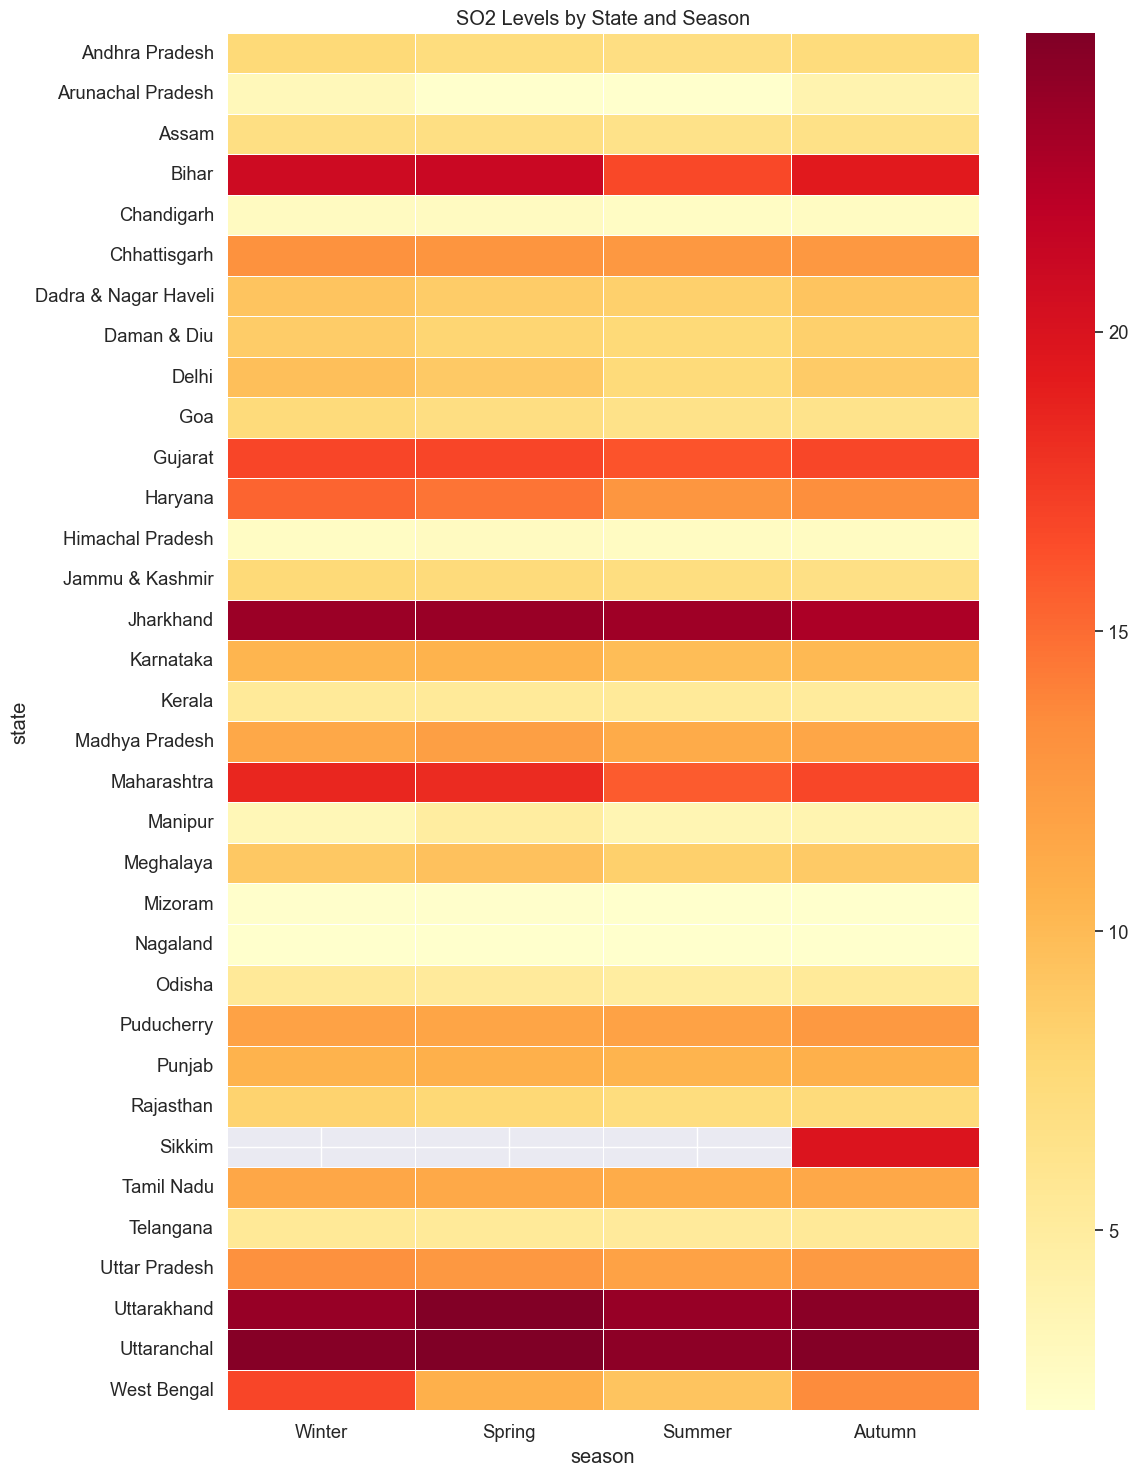

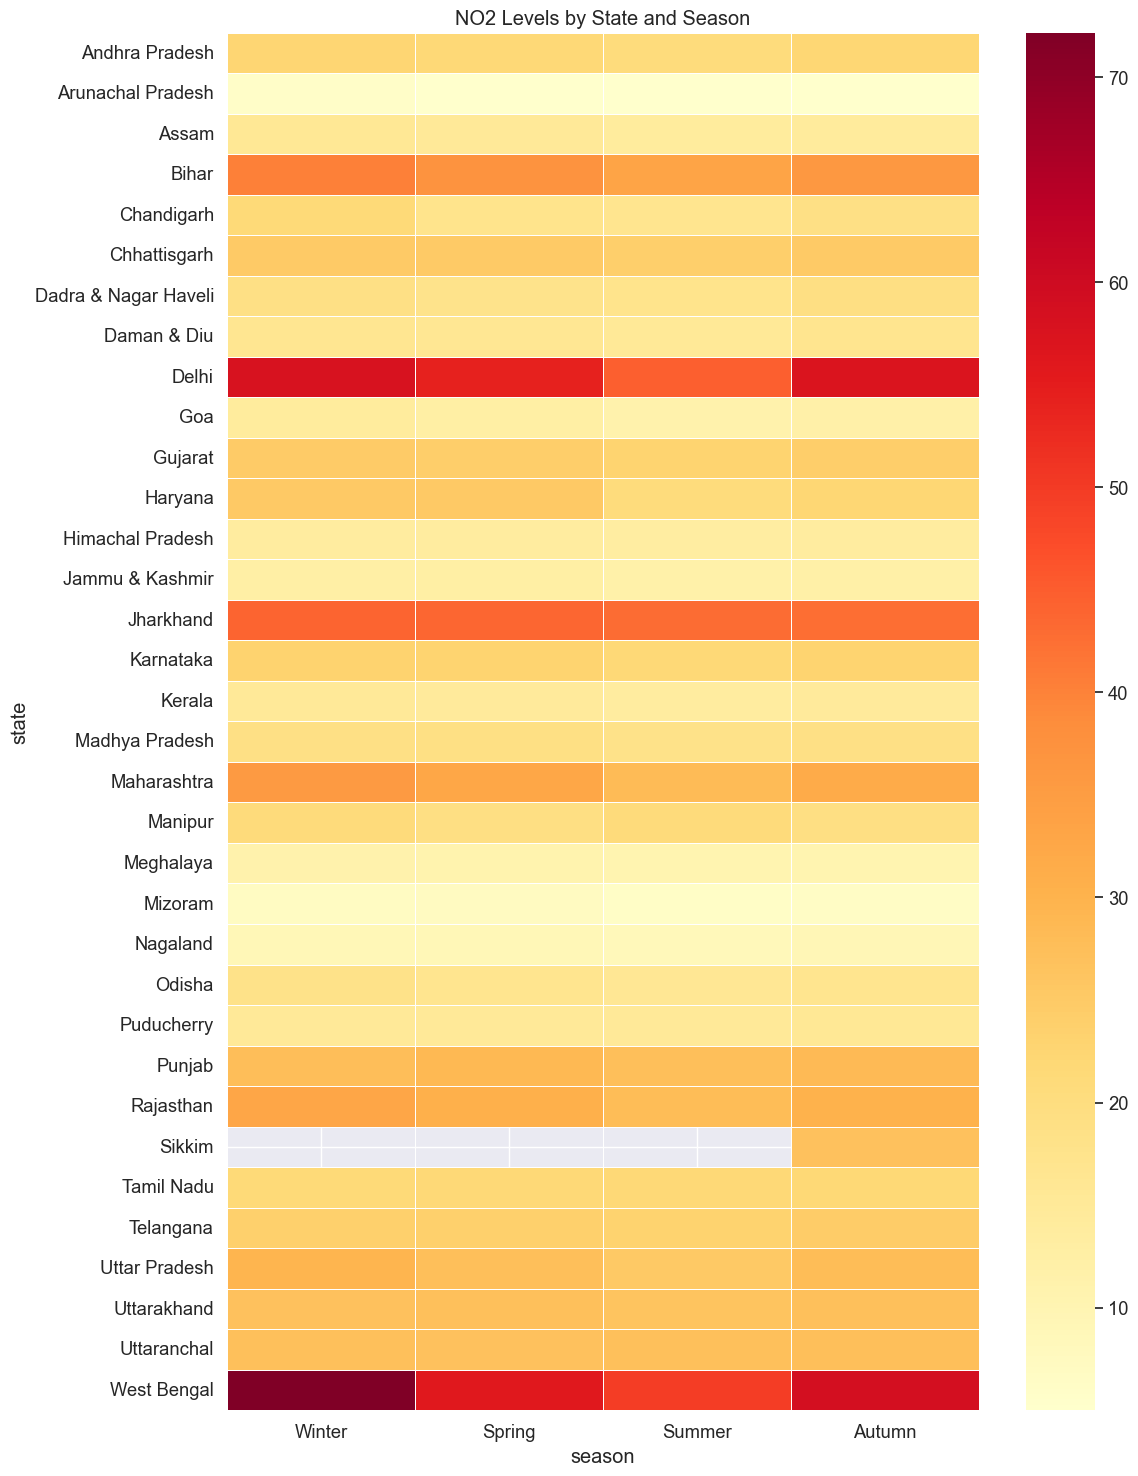

In [20]:
# Create pivot tables for heatmaps
so2_pivot = pd.pivot_table(seasonal_data, values='so2', index='state', columns='season')
no2_pivot = pd.pivot_table(seasonal_data, values='no2', index='state', columns='season')

# Reorder columns for intuitive seasonal flow
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
so2_pivot = so2_pivot[season_order]
no2_pivot = no2_pivot[season_order]

# Plot heatmaps
plt.figure(figsize=(12, 15))
sns.heatmap(so2_pivot, cmap='YlOrRd', annot=False, linewidths=.5)
plt.title('SO2 Levels by State and Season')
plt.tight_layout()
plt.savefig('so2_seasonal_heatmap.png')
plt.show()

plt.figure(figsize=(12, 15))
sns.heatmap(no2_pivot, cmap='YlOrRd', annot=False, linewidths=.5)
plt.title('NO2 Levels by State and Season')
plt.tight_layout()
plt.savefig('no2_seasonal_heatmap.png')
plt.show()

In [21]:
# Perform ANOVA or similar statistical tests to confirm seasonal differences
from scipy import stats

# Test if there are significant differences in SO2 levels between seasons
so2_winter = data[data['season'] == 'Winter']['so2'].dropna()
so2_spring = data[data['season'] == 'Spring']['so2'].dropna()
so2_summer = data[data['season'] == 'Summer']['so2'].dropna()
so2_autumn = data[data['season'] == 'Autumn']['so2'].dropna()

f_stat, p_value = stats.f_oneway(so2_winter, so2_spring, so2_summer, so2_autumn)
print(f"ANOVA test for SO2 across seasons: F-statistic = {f_stat}, p-value = {p_value}")
print(f"Significant difference? {'Yes' if p_value < 0.05 else 'No'}")

# Test if there are significant differences in NO2 levels between seasons
no2_winter = data[data['season'] == 'Winter']['no2'].dropna()
no2_spring = data[data['season'] == 'Spring']['no2'].dropna()
no2_summer = data[data['season'] == 'Summer']['no2'].dropna()
no2_autumn = data[data['season'] == 'Autumn']['no2'].dropna()

f_stat, p_value = stats.f_oneway(no2_winter, no2_spring, no2_summer, no2_autumn)
print(f"\nANOVA test for NO2 across seasons: F-statistic = {f_stat}, p-value = {p_value}")
print(f"Significant difference? {'Yes' if p_value < 0.05 else 'No'}")

ANOVA test for SO2 across seasons: F-statistic = 260.3289168264911, p-value = 8.397906588280615e-169
Significant difference? Yes

ANOVA test for NO2 across seasons: F-statistic = 815.70477520746, p-value = 0.0
Significant difference? Yes


In [22]:
# Calculate which season has the worst air quality parameters
worst_season = overall_seasonal_avg.set_index('season').idxmax()
print("Seasons with worst air quality parameters:")
print(worst_season)

# Calculate which states have the worst air quality in each season
worst_states_by_season = seasonal_data.groupby('season').apply(
    lambda x: pd.Series({
        'worst_so2_state': x.loc[x['so2'].idxmax(), 'state'] if not x['so2'].isna().all() else 'No data',
        'worst_no2_state': x.loc[x['no2'].idxmax(), 'state'] if not x['no2'].isna().all() else 'No data',
        'worst_rspm_state': x.loc[x['rspm'].idxmax(), 'state'] if not x['rspm'].isna().all() else 'No data',
        'worst_spm_state': x.loc[x['spm'].idxmax(), 'state'] if not x['spm'].isna().all() else 'No data'
    })
)

print("\nStates with worst air quality parameters by season:")
print(worst_states_by_season)

# Generate a summary report
print("\n========== AIR QUALITY ANALYSIS BY SEASON AND REGION ==========")
print(f"Data period: {data['year'].min()} to {data['year'].max()}")
print(f"Total number of records: {len(data)}")
print(f"Number of states/regions analyzed: {len(data['state'].unique())}")

print("\nKey findings:")
print("1. Overall seasonal patterns:")
for param in ['so2', 'no2', 'rspm', 'spm']:
    if param in worst_season.index:
        print(f"   - {param.upper()} levels are highest during {worst_season[param]} season")

print("\n2. Regional hotspots by season:")
for season in seasons:
    print(f"   - {season}: High pollution levels observed in", end=" ")
    try:
        states = worst_states_by_season.loc[season].values
        print(", ".join([s for s in states if s != 'No data']))
    except:
        print("data unavailable")

print("\n==============================================================")

Seasons with worst air quality parameters:
so2      Winter
no2      Winter
rspm     Winter
spm      Winter
pm2_5    Winter
dtype: object

States with worst air quality parameters by season:
       worst_so2_state worst_no2_state worst_rspm_state worst_spm_state
season                                                                 
Autumn     Uttaranchal     West Bengal            Delhi           Delhi
Spring     Uttaranchal     West Bengal            Delhi           Delhi
Summer     Uttaranchal     West Bengal           Punjab           Delhi
Winter     Uttaranchal     West Bengal            Delhi           Delhi

========== AIR QUALITY ANALYSIS BY SEASON AND REGION ==========
Data period: 1987.0 to 2015.0
Total number of records: 435742
Number of states/regions analyzed: 37

Key findings:
1. Overall seasonal patterns:
   - SO2 levels are highest during Winter season
   - NO2 levels are highest during Winter season
   - RSPM levels are highest during Winter season
   - SPM levels are 

/var/folders/xj/mwp5pjc12yd_2c1tnd3t29s00000gp/T/ipykernel_42017/1250049804.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  worst_states_by_season = seasonal_data.groupby('season').apply(
